In [38]:
import pandas as pd
import numpy as np

In [11]:
store = pd.read_csv("../data/raw/store.csv")

store.head(2)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"


In [12]:
train = pd.read_csv("../data/raw/train.csv")

train.head(2)

/var/folders/94/1mgtxbsd2_781zg_4p5613q40000gn/T/ipykernel_18431/160837591.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1


In [13]:
test = pd.read_csv("../data/raw/test.csv")

test.head(2)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0


In [14]:
train.shape

(1017209, 9)

In [15]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [16]:
train.dtypes

Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [19]:
train.describe(include='all')

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1017209,1.017209e+06
unique,NaN,NaN,942,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,2015-07-31,NaN,NaN,NaN,NaN,0,NaN
freq,NaN,NaN,1115,NaN,NaN,NaN,NaN,855087,NaN
mean,5.584297e+02,3.998341e+00,NaN,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,NaN,1.786467e-01
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,NaN,3.830564e-01
min,1.000000e+00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00
25%,2.800000e+02,2.000000e+00,NaN,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00
50%,5.580000e+02,4.000000e+00,NaN,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,NaN,0.000000e+00
75%,8.380000e+02,6.000000e+00,NaN,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,NaN,0.000000e+00


In [21]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [26]:
train = train.loc[train['Open'] != 0]
train = train.loc[train['Sales'] != 0]

In [27]:
train.shape

(844338, 9)

In [28]:
train.drop(columns=['Customers'], inplace=True)

In [29]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday'],
      dtype='object')

In [30]:
df = train.merge(store, on="Store", how="left")
df.head(2)

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"


In [31]:
df["Date"] = pd.to_datetime(df["Date"])

df.head(2)

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"


In [32]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2                            0
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64

In [39]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna(np.nan)

In [45]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'year', 'month',
       'day', 'week_of_year', 'day_of_week', 'is_weekend', 'is_month_start',
       'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_28'],
      dtype='object')

In [40]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

In [41]:
df.head(2)

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,Promo2SinceYear,PromoInterval,year,month,day,week_of_year,day_of_week,is_weekend,is_month_start,is_month_end
0,1,5,2015-07-31,5263,1,1,0,1,c,a,...,0.0,NaN,2015,7,31,31,4,0,0,1
1,2,5,2015-07-31,6064,1,1,0,1,a,a,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,4,0,0,1


In [55]:
for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = df.groupby("Store")["Sales"].shift(lag)

In [57]:
df.tail()

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,day,week_of_year,day_of_week,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_28
844333,682,2,2013-01-01,3375,1,0,a,1,b,a,...,1,1,1,0,1,0,10526.0,14481.0,11189.0,10543.0
844334,733,2,2013-01-01,10765,1,0,a,1,b,b,...,1,1,1,0,1,0,12477.0,12577.0,13060.0,13019.0
844335,769,2,2013-01-01,5035,1,0,a,1,b,b,...,1,1,1,0,1,0,7276.0,7659.0,7782.0,7875.0
844336,948,2,2013-01-01,4491,1,0,a,1,b,b,...,1,1,1,0,1,0,3643.0,4260.0,4624.0,4422.0
844337,1097,2,2013-01-01,5961,1,0,a,1,b,b,...,1,1,1,0,1,0,6688.0,8057.0,8138.0,8536.0


In [58]:
shifted = df.groupby("Store")["Sales"].shift(1)

df["rolling_mean_7"] = shifted.groupby(df["Store"]).rolling(7).mean().reset_index(level=0, drop=True)
df["rolling_mean_14"] = shifted.groupby(df["Store"]).rolling(14).mean().reset_index(level=0, drop=True)
df["rolling_std_7"] = shifted.groupby(df["Store"]).rolling(7).std().reset_index(level=0, drop=True)

In [59]:
df = df.dropna().copy()

In [60]:
df.head(2)

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
27053,209,5,2015-07-03,7420,1,1,0,0,a,c,...,0,0,0,5720.0,6323.0,7167.0,8912.0,5770.142857,6123.571429,1598.091198
27118,274,5,2015-07-03,6713,1,1,0,0,b,b,...,0,0,0,4690.0,5873.0,6017.0,6975.0,5606.571429,5825.357143,885.056092


In [61]:
train_df = df[df["Date"] < "2015-01-01"].copy()
val_df = df[(df["Date"] >= "2015-01-01") & (df["Date"] < "2015-06-01")].copy()
test_df = df[df["Date"] >= "2015-06-01"].copy()

In [62]:
feature_cols = [
    "Store",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Promo2",
    "month",
    "day",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",
]

In [63]:
y_pred_baseline = test_df["lag_7"]

In [79]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not installed. Run: pip install lightgbm")

In [66]:
# Expected columns
target_col = "Sales"
date_col = "Date"

assert target_col in df.columns, f"Missing target column: {target_col}"
assert date_col in df.columns, f"Missing date column: {date_col}"

df = df.copy()
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(["Store", date_col]).reset_index(drop=True)

print(df.shape)
print(df[[date_col, target_col]].head())

(405058, 32)
        Date  Sales
0 2013-01-02   4422
1 2013-01-03   4159
2 2013-01-04   4484
3 2013-01-05   2342
4 2013-01-07   6775


In [67]:
feature_cols = [
    "Store",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Promo2",
    "month",
    "day",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",
]

# Keep only features that exist
feature_cols = [col for col in feature_cols if col in df.columns]

print("Using features:")
print(feature_cols)

Using features:
['Store', 'Promo', 'SchoolHoliday', 'StateHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'month', 'day', 'week_of_year', 'day_of_week', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']


In [68]:
required_cols = feature_cols + [target_col, date_col]
train_df = df.dropna(subset=required_cols).copy()

print("Shape after dropping NA in required columns:", train_df.shape)

Shape after dropping NA in required columns: (405058, 32)


In [69]:
unique_dates = np.sort(train_df[date_col].unique())

n_dates = len(unique_dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_data = train_df[train_df[date_col].isin(train_dates)].copy()
val_data = train_df[train_df[date_col].isin(val_dates)].copy()
test_data = train_df[train_df[date_col].isin(test_dates)].copy()

print("Train shape:", train_data.shape)
print("Val shape:", val_data.shape)
print("Test shape:", test_data.shape)

print("Train date range:", train_data[date_col].min(), "to", train_data[date_col].max())
print("Val date range:", val_data[date_col].min(), "to", val_data[date_col].max())
print("Test date range:", test_data[date_col].min(), "to", test_data[date_col].max())

Train shape: (290202, 32)
Val shape: (52385, 32)
Test shape: (62471, 32)
Train date range: 2013-01-01 00:00:00 to 2014-10-01 00:00:00
Val date range: 2014-10-02 00:00:00 to 2015-02-15 00:00:00
Test date range: 2015-02-16 00:00:00 to 2015-07-03 00:00:00


In [70]:
X_train = train_data[feature_cols].copy()
y_train = train_data[target_col].copy()

X_val = val_data[feature_cols].copy()
y_val = val_data[target_col].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data[target_col].copy()

In [71]:
categorical_cols = [
    col for col in ["Store", "StateHoliday", "StoreType", "Assortment"]
    if col in X_train.columns
]

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Categorical columns:", categorical_cols)

Categorical columns: ['Store', 'StateHoliday', 'StoreType', 'Assortment']


In [73]:
baseline_col = "lag_7" if "lag_7" in X_test.columns else "lag_1"
assert baseline_col in X_test.columns, "Need lag_7 or lag_1 for baseline"

baseline_pred = X_test[baseline_col].values

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred)

print(f"Baseline ({baseline_col}) MAE:  {baseline_mae:.4f}")
print(f"Baseline ({baseline_col}) RMSE: {baseline_rmse:.4f}")

Baseline (lag_7) MAE:  2358.5878
Baseline (lag_7) RMSE: 9098309.5883


In [80]:
if not LIGHTGBM_AVAILABLE:
    raise ImportError("LightGBM is not installed. Please install with: pip install lightgbm")

model = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",
    callbacks=[],
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2729
[LightGBM] [Info] Number of data points in the train set: 290202, number of used features: 21
[LightGBM] [Info] Start training from score 6436.991723


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [81]:
from lightgbm import early_stopping, log_evaluation

model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",
    categorical_feature=categorical_cols,
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(100),
    ],
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2729
[LightGBM] [Info] Number of data points in the train set: 290202, number of used features: 21
[LightGBM] [Info] Start training from score 6436.991723
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 1.17739e+06
[200]	valid_0's l2: 887227
[300]	valid_0's l2: 816329
[400]	valid_0's l2: 781093
[500]	valid_0's l2: 757542
[600]	valid_0's l2: 744748
[700]	valid_0's l2: 731590
[800]	valid_0's l2: 723974
[900]	valid_0's l2: 719316
[1000]	valid_0's l2: 714611
[1100]	valid_0's l2: 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [83]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = mean_squared_error(y_val, val_pred)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = mean_squared_error(y_test, test_pred)

print("\nLightGBM Results")
print(f"Validation MAE:  {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test MAE:        {test_mae:.4f}")
print(f"Test RMSE:       {test_rmse:.4f}")


LightGBM Results
Validation MAE:  590.0018
Validation RMSE: 695931.4135
Test MAE:        579.8689
Test RMSE:       701572.8494


In [84]:
results_df = pd.DataFrame({
    "Model": [f"Baseline ({baseline_col})", "LightGBM"],
    "MAE": [baseline_mae, test_mae],
    "RMSE": [baseline_rmse, test_rmse],
})

results_df.sort_values("RMSE")

,Model,MAE,RMSE
1,LightGBM,579.868907,7.015728e+05
0,Baseline (lag_7),2358.587825,9.098310e+06


In [85]:
test_results = test_data[[date_col, "Store", target_col]].copy()
test_results["baseline_pred"] = baseline_pred
test_results["model_pred"] = test_pred
test_results["abs_error"] = np.abs(test_results[target_col] - test_results["model_pred"])

test_results.head()

,Date,Store,Sales,baseline_pred,model_pred,abs_error
646,2015-02-16,2,7478,3755.0,7100.043070,377.956930
647,2015-02-17,2,6113,4666.0,6056.473185,56.526815
648,2015-02-18,2,6178,4035.0,6326.673171,148.673171
649,2015-02-19,2,5842,4022.0,5339.565492,502.434508
650,2015-02-20,2,4727,3032.0,5017.784009,290.784009


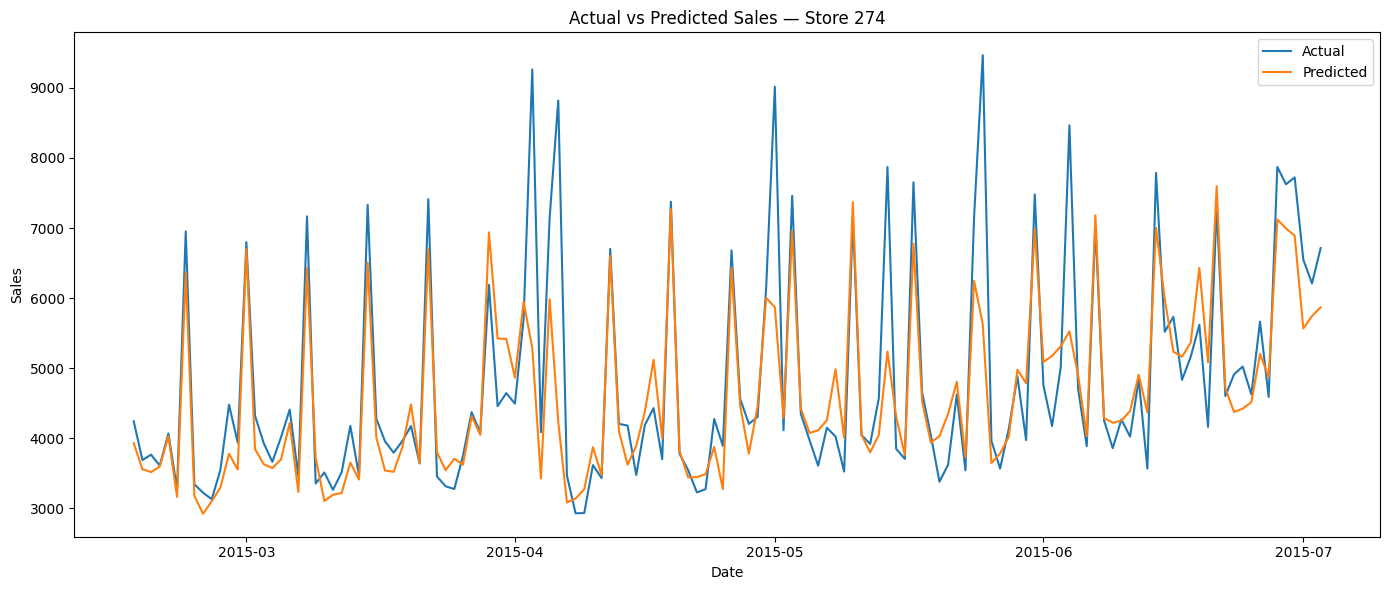

In [86]:
example_store = test_results["Store"].mode().iloc[0]

plot_df = test_results[test_results["Store"] == example_store].sort_values(date_col).copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_df[date_col], plot_df[target_col], label="Actual")
plt.plot(plot_df[date_col], plot_df["model_pred"], label="Predicted")
plt.title(f"Actual vs Predicted Sales — Store {example_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
0,Store,15694
9,day,5552
11,day_of_week,5517
15,lag_1,4211
10,week_of_year,4032
21,rolling_std_7,3159
16,lag_7,2854
20,rolling_mean_14,2759
19,rolling_mean_7,2522
17,lag_14,2496


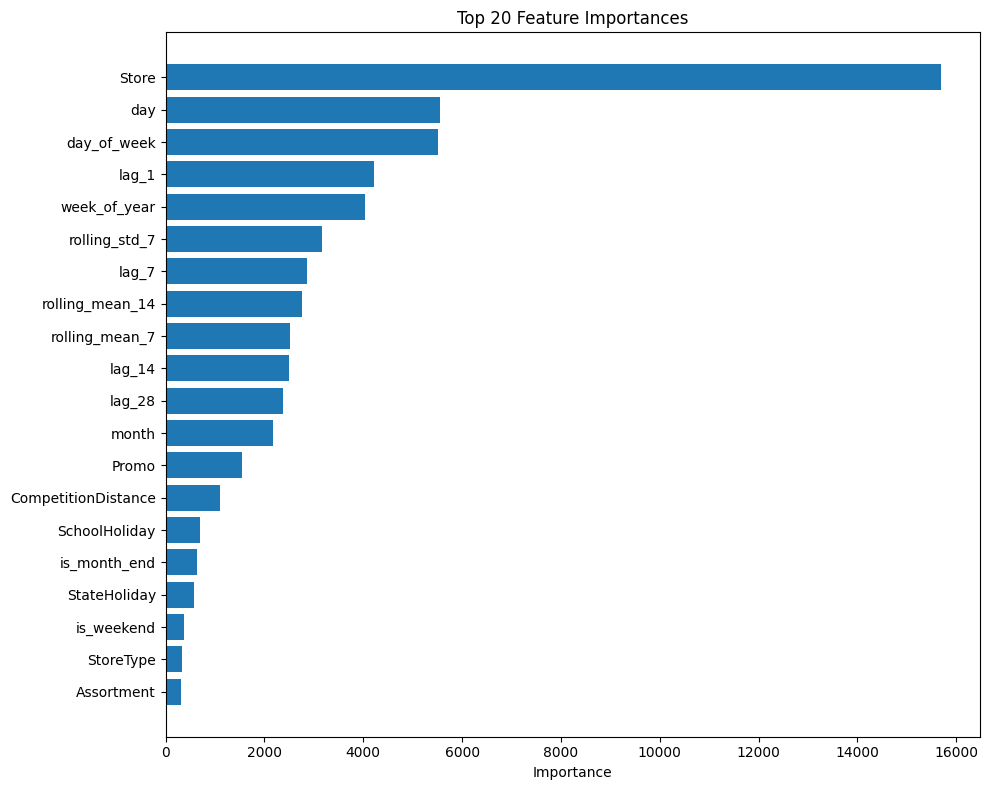

In [88]:
top_n = 20
plot_importance = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [89]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "metrics_summary.csv", index=False)
test_results.to_csv(output_dir / "test_predictions.csv", index=False)
importance_df.to_csv(output_dir / "feature_importance.csv", index=False)

metrics = {
    "baseline_model": baseline_col,
    "baseline_mae": float(baseline_mae),
    "baseline_rmse": float(baseline_rmse),
    "val_mae": float(val_mae),
    "val_rmse": float(val_rmse),
    "test_mae": float(test_mae),
    "test_rmse": float(test_rmse),
    "n_train_rows": int(len(train_data)),
    "n_val_rows": int(len(val_data)),
    "n_test_rows": int(len(test_data)),
    "features": feature_cols,
}

with open(output_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved outputs to:", output_dir.resolve())

Saved outputs to: /Users/christian/Documents/PhD/GitHub/demand_forecasting_ml/notebooks/outputs


In [91]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

model_log = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model_log.fit(
    X_train,
    y_train_log,
    eval_set=[(X_val, y_val_log)],
    eval_metric="l2",
)

test_pred_log = model_log.predict(X_test)
test_pred_log = np.expm1(test_pred_log)

test_mae_log = mean_absolute_error(y_test, test_pred_log)
test_rmse_log = mean_squared_error(y_test, test_pred_log)

print(f"Log-target Test MAE:  {test_mae_log:.4f}")
print(f"Log-target Test RMSE: {test_rmse_log:.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2729
[LightGBM] [Info] Number of data points in the train set: 290202, number of used features: 21
[LightGBM] [Info] Start training from score 8.687925
Log-target Test MAE:  585.9832
Log-target Test RMSE: 720102.5812
